In this project, I perform an end-to-end data analytics workflow on an online food delivery dataset using Python in Jupyter Notebook. The objective is to analyze revenue performance, customer spending behavior, platform contribution, delivery efficiency, and refund-related issues.

The dataset contains randomly generated order date and time values for simulation purposes; therefore, the analysis focuses primarily on revenue trends, refund patterns, customer contribution, and operational performance rather than time-based seasonality.

The project follows a structured approach starting with data loading, followed by data cleaning and preprocessing, exploratory data analysis (EDA), visualizations, and finally business insight generation to support data-driven decision-making.

Project Aims

The primary aim of this project is to analyze e-commerce order data to extract actionable business insights related to revenue generation, customer behavior, and operational efficiency.

The specific objectives are:

To calculate total revenue and average order value.

To identify the platform generating the highest revenue.

To determine the overall refund percentage and assess its business impact.

To evaluate delivery time performance.

To identify top revenue-contributing customers and analyze revenue concentration.

Before starting the data analysis, the required Python libraries are imported. These libraries provide essential tools for data manipulation, numerical computation, and data visualization.

Pandas is used for loading and handling structured tabular data.
NumPy is used for performing numerical and mathematical operations.
Matplotlib and Seaborn are used for creating visualizations to explore patterns and trends in the data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


The dataset is loaded into the Jupyter Notebook using the read_csv() function from the Pandas library. The file path specifies the location of the CSV file on the local system, and the data is stored in a DataFrame for further analysis.

In [2]:
ecom_data = pd.read_csv("C:/Users/Hp/OneDrive/Desktop/previous/2023_Resume/Data Analytics/Main_Project/Date changed dataset curremtly using file/csv file original/ECommerce Analytics SwiggyZomatoBlinkit.csv")

The df.head() function is used to display the first few rows of the dataset. This helps in quickly understanding the structure of the data, column names, and the type of values present in each column. It serves as an initial validation step to ensure that the data has been loaded correctly.

In [3]:
ecom_data.head()

,Order ID,Customer ID,Platform,Order Date & Time,Delivery Time (Minutes),Product Category,Order Value (INR),Customer Feedback,Service Rating,Delivery Delay,Refund Requested
0,ORD000001,CUST2824,JioMart,2024-09-26 06:14,30,Fruits & Vegetables,382,"Fast delivery, great service!",5,No,No
1,ORD000002,CUST1409,Blinkit,2025-11-24 02:39,16,Dairy,279,Quick and reliable!,5,No,No
2,ORD000003,CUST5506,JioMart,2024-02-17 09:39,25,Beverages,599,Items missing from order.,2,No,Yes
3,ORD000004,CUST5012,JioMart,2025-05-10 02:12,42,Beverages,946,Items missing from order.,2,Yes,Yes
4,ORD000005,CUST4657,Blinkit,2025-07-30 00:46,30,Beverages,334,"Fast delivery, great service!",5,No,No


The df.shape function is used to identify the number of rows and columns present in the dataset.

Each row represents a single order placed by a customer on a specific platform.

Each column represents an attribute related to the order, such as order date and time, delivery duration, product category, order value, customer feedback, service rating, delivery delay, and refund request status.

This step is important to confirm that the dataset contains a sufficient number of records and relevant features to perform meaningful analysis and meet the project requirements.

In [4]:
ecom_data.shape

(100000, 11)

The df.columns command is used to view all column names in the dataset. This provides clarity on the features available for analysis and helps in planning data cleaning, feature engineering, and exploratory analysis steps.

In [5]:
ecom_data.columns

Index(['Order ID', 'Customer ID', 'Platform', 'Order Date & Time',
       'Delivery Time (Minutes)', 'Product Category', 'Order Value (INR)',
       'Customer Feedback', 'Service Rating', 'Delivery Delay',
       'Refund Requested'],
      dtype='object')

The df.info() function provides a concise summary of the dataset, including the total number of rows and columns, column names, data types, and the count of non-null values for each column. This step is crucial for identifying missing values and verifying whether the data types are appropriate for analysis. The insights from this step guide the data cleaning and preprocessing process, such as handling null values and converting data types where required.

In [6]:
ecom_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column                   Non-Null Count   Dtype 
---  ------                   --------------   ----- 
 0   Order ID                 100000 non-null  object
 1   Customer ID              100000 non-null  object
 2   Platform                 100000 non-null  object
 3   Order Date & Time        100000 non-null  object
 4   Delivery Time (Minutes)  100000 non-null  int64 
 5   Product Category         100000 non-null  object
 6   Order Value (INR)        100000 non-null  int64 
 7   Customer Feedback        100000 non-null  object
 8   Service Rating           100000 non-null  int64 
 9   Delivery Delay           100000 non-null  object
 10  Refund Requested         100000 non-null  object
dtypes: int64(3), object(8)
memory usage: 8.4+ MB


The df.describe() function provides a statistical summary of the numerical columns in the dataset, including measures such as mean, minimum, maximum, and quartiles. This helps in understanding the overall distribution of key numerical variables and identifying potential outliers.

In [7]:
ecom_data.describe()

,Delivery Time (Minutes),Order Value (INR),Service Rating
count,100000.000000,100000.000000,100000.000000
mean,29.536140,590.994400,3.240790
std,9.958933,417.409058,1.575962
min,5.000000,50.000000,1.000000
25%,23.000000,283.000000,2.000000
50%,30.000000,481.000000,3.000000
75%,36.000000,770.000000,5.000000
max,76.000000,2000.000000,5.000000


The df.isnull().sum() function is used to identify the number of missing values in each column of the dataset. This helps in understanding the extent of missing data and deciding the appropriate data cleaning strategy. In this dataset, no null values are present across any columns, indicating that the data is complete and does not require missing value treatment.

In [8]:
ecom_data.isnull().sum()

Order ID                   0
Customer ID                0
Platform                   0
Order Date & Time          0
Delivery Time (Minutes)    0
Product Category           0
Order Value (INR)          0
Customer Feedback          0
Service Rating             0
Delivery Delay             0
Refund Requested           0
dtype: int64

The df.duplicated().sum() function is used to check for duplicate records in the dataset. It returns the total number of duplicate rows present in the data.The result indicates that no duplicate records are present in the dataset.

In [9]:
ecom_data.duplicated().sum()



np.int64(0)

In this step, the data types of key columns were corrected to ensure accurate analysis. The order date and time column was converted into a datetime format, while the delivery delay and refund request columns were transformed into boolean values to support efficient computation and aggregation.

In [10]:
ecom_data['Order Date & Time'] = pd.to_datetime(
    ecom_data ['Order Date & Time'],
    errors='coerce'
)
ecom_data['Delivery Delay'] = ecom_data['Delivery Delay'].map({'Yes': True, 'No': False})
ecom_data['Refund Requested'] = ecom_data['Refund Requested'].map({'Yes': True, 'No': False})



This step is used to verify the data types of each column so that numerical, categorical, and datetime fields are handled correctly during analysis.

In [11]:
ecom_data.dtypes

Order ID                           object
Customer ID                        object
Platform                           object
Order Date & Time          datetime64[ns]
Delivery Time (Minutes)             int64
Product Category                   object
Order Value (INR)                   int64
Customer Feedback                  object
Service Rating                      int64
Delivery Delay                       bool
Refund Requested                     bool
dtype: object

Time-based derived features such as order hour, day, and month were created from the order timestamp to analyze customer ordering patterns and peak demand periods.

In [12]:
ecom_data['Order Hour'] = ecom_data['Order Date & Time'].dt.hour
ecom_data['Order Day'] = ecom_data['Order Date & Time'].dt.day_name()
ecom_data['Order Month'] = ecom_data['Order Date & Time'].dt.month_name()



Order values were segmented into low, medium, high, and premium categories based on the observed minimum and maximum order values. This categorization helps analyze customer spending behavior across different product categories.

In [13]:
ecom_data['Order Value Category'] = pd.cut(
    ecom_data['Order Value (INR)'],
    bins=[49, 300, 700, 1200, 2000],
    labels=['Low', 'Medium', 'High', 'Premium']
)


Service ratings were grouped into performance categories for easier interpretation of customer satisfaction levels.

In [14]:
ecom_data['Rating Category'] = pd.cut(
    ecom_data['Service Rating'],
    bins=[1, 2, 3, 4, 5],
    labels=['Poor', 'Average', 'Good', 'Excellent']
)


An issue flag was created to identify orders affected by delivery delays or refund requests.

In [15]:
ecom_data['Order Issue'] = (
    ecom_data['Delivery Delay'] | ecom_data['Refund Requested']
)


Customer feedback text was analyzed using a rule-based approach. A for loop combined with conditional statements was applied to classify feedback into positive, negative, and neutral categories based on keyword matching.

In [16]:
positive_words = [
    'excellent', 'loved', 'great', 'good', 'quick',
    'reliable', 'satisfied', 'fast'
]
negative_words = [
    'horrible', 'missing', 'rude', 'late',
    'not happy', 'wrong', 'disappointed', 'not fresh'
]
sentiment = []

for feedback in ecom_data['Customer Feedback']:
    feedback = feedback.lower()

    if any(word in feedback for word in positive_words):
        sentiment.append('Positive')

    elif any(word in feedback for word in negative_words):
        sentiment.append('Negative')

    else:
        sentiment.append('Neutral')

ecom_data['Customer Sentiment'] = sentiment
ecom_data[['Customer Feedback', 'Customer Sentiment']].head()



,Customer Feedback,Customer Sentiment
0,"Fast delivery, great service!",Positive
1,Quick and reliable!,Positive
2,Items missing from order.,Negative
3,Items missing from order.,Negative
4,"Fast delivery, great service!",Positive


Delivery Time (Minutes) was categorized into three segments — Fast, Moderate, and Slow — based on observed minimum and maximum delivery durations to better analyze operational efficiency.

In [17]:
ecom_data['Delivery Speed'] = pd.cut(
    ecom_data['Delivery Time (Minutes)'],
    bins=[4,20,45,76],
    labels=['Fast','Moderate','Slow']
)


Key Performance Indicators (KPIs)



In [18]:
total_revenue = ecom_data['Order Value (INR)'].sum()

average_order_value = ecom_data['Order Value (INR)'].mean()

refund_rate = ecom_data['Refund Requested'].mean() * 100

average_delivery_time = ecom_data['Delivery Time (Minutes)'].mean()

total_orders = len(ecom_data)

print("Total Revenue:", total_revenue)
print("Average Order Value:", average_order_value)
print("Refund Rate (%):", round(refund_rate,2))
print("Average Delivery Time:", round(average_delivery_time,2))
print("Total Orders:", total_orders)

Total Revenue: 59099440
Average Order Value: 590.9944
Refund Rate (%): 45.82
Average Delivery Time: 29.54
Total Orders: 100000


The analysis of 100,000 orders provides the following key business insights:

The platform generated a total revenue of ₹59,099,440, indicating strong transaction volume and consistent customer demand across platforms.

The average order value (AOV) of ₹590.99 suggests that customers typically spend around ₹600 per transaction, reflecting stable basket sizes and moderate purchasing behavior.

The average delivery time of 29.54 minutes aligns with quick-commerce industry standards (under 30 minutes), indicating operational efficiency in fulfilling orders.

However, the refund rate of 45.82% is significantly high. In a real-world business environment, refund rates typically remain in single digits. This suggests:

Potential service or product quality issues

Delivery-related dissatisfaction

Or that the dataset is simulated for analytical purposes

Overall, while revenue generation and delivery performance appear stable, the high refund rate highlights an area that would require immediate operational investigation and improvement.

Which platform generates the highest revenue?

In [19]:
ecom_data.groupby('Platform')['Order Value (INR)'].sum()

Platform
Blinkit             19705084
JioMart             19562372
Swiggy Instamart    19831984
Name: Order Value (INR), dtype: int64

Among the three platforms, Swiggy Instamart generated the highest total revenue, slightly outperforming Blinkit and JioMart.

However, the revenue difference between platforms is relatively small, indicating that all three platforms perform at a similar scale in terms of sales volume.

Which customers contribute most to total revenue?

In [20]:
top_customers = (
    ecom_data.groupby('Customer ID')['Order Value (INR)']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_customers

Customer ID
CUST9682    16255
CUST1605    16185
CUST9084    15547
CUST5386    15467
CUST2175    15209
CUST8779    14782
CUST8613    14729
CUST5009    14712
CUST5333    14601
CUST9482    14545
Name: Order Value (INR), dtype: int64

The top 10 customers each generated over ₹14,500 in total revenue, with CUST9682 being the highest contributor (₹16,255). This indicates that a small group of high-value customers plays a major role in overall revenue generation.

UNIVARIATE ANALYSIS


Delivery Time (Minutes)-
Univariate analysis of delivery time was conducted to understand the overall distribution, central tendency, and variability of order fulfillment duration.

In [21]:
ecom_data['Delivery Time (Minutes)'].describe()


count    100000.000000
mean         29.536140
std           9.958933
min           5.000000
25%          23.000000
50%          30.000000
75%          36.000000
max          76.000000
Name: Delivery Time (Minutes), dtype: float64

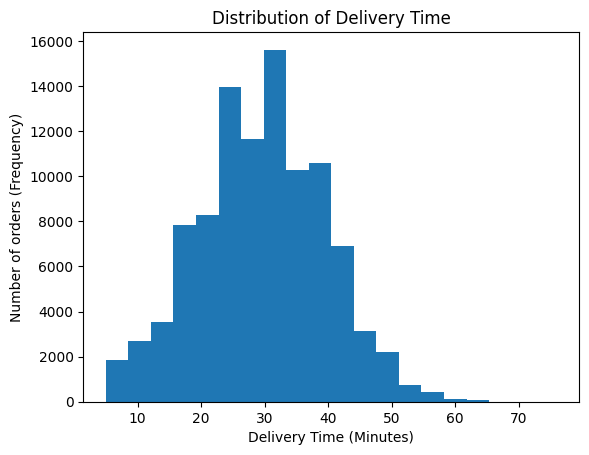

In [22]:

plt.hist(ecom_data['Delivery Time (Minutes)'], bins=20)
plt.xlabel("Delivery Time (Minutes)")
plt.ylabel("Number of orders (Frequency)")
plt.title("Distribution of Delivery Time")
plt.show()

The majority of orders were delivered within 20–40 minutes.

The distribution appears approximately normally distributed, centered around 30 minutes.

Very few deliveries took less than 10 minutes or more than 60 minutes.

This indicates that the typical delivery time for most platforms falls within the 20–40 minute range.

Platform Distribution

In [23]:
ecom_data['Platform'].value_counts()


Platform
Swiggy Instamart    33449
Blinkit             33424
JioMart             33127
Name: count, dtype: int64

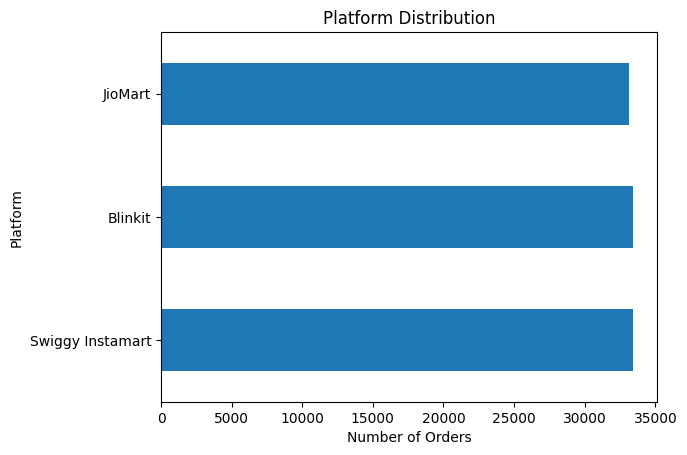

In [24]:
ecom_data['Platform'].value_counts().plot(kind='barh')
plt.title("Platform Distribution")
plt.xlabel("Number of Orders")
plt.show()

The dataset contains orders from three platforms: Swiggy Instamart, Blinkit, and JioMart.

Order distribution across platforms is relatively balanced.

Swiggy Instamart has the highest number of orders, followed closely by Blinkit.

JioMart has the lowest order count, but the difference is minimal.

This suggests that customer demand is fairly evenly distributed across all three platforms.

Order Value (INR)

In [25]:
ecom_data['Order Value (INR)'].describe()


count    100000.000000
mean        590.994400
std         417.409058
min          50.000000
25%         283.000000
50%         481.000000
75%         770.000000
max        2000.000000
Name: Order Value (INR), dtype: float64

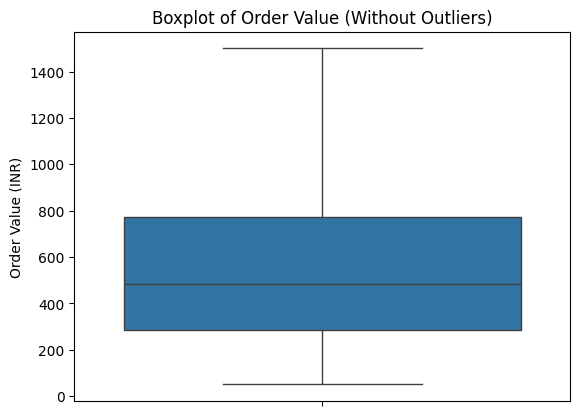

In [26]:
sns.boxplot(y=ecom_data['Order Value (INR)'], showfliers=False)
plt.title("Boxplot of Order Value (Without Outliers)")
plt.show()


The median order value is approximately ₹480–₹500, indicating that half of the orders fall below this amount.

The middle 50% of orders (IQR) lie between approximately ₹280 and ₹770, showing moderate variability in customer spending.

The distribution shows a slight right skew, as the upper whisker is longer than the lower whisker.

Most customers place orders in the ₹300 to ₹800 range, which appears to be the common spending range.

Even after removing outliers from visualization, the data indicates that higher-value purchases occur but are less frequent.

The spread suggests that while average spending is moderate, there is noticeable variation in customer purchasing behavior.

Customer Sentiment Distribution

In [27]:
ecom_data['Customer Sentiment'].value_counts()


Customer Sentiment
Positive    46477
Negative    45819
Neutral      7704
Name: count, dtype: int64

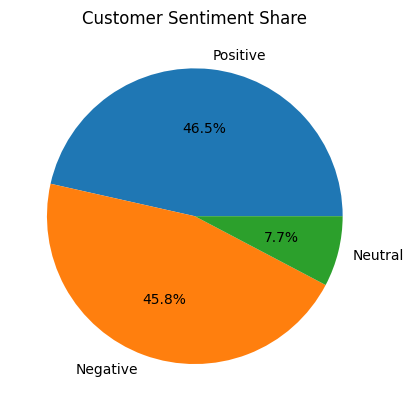

In [28]:
ecom_data['Customer Sentiment'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Customer Sentiment Share")
plt.ylabel("")
plt.show()


46.5% of customers gave positive reviews, indicating nearly half of the customers are satisfied with the service.

45.8% of customers gave negative reviews, which is almost equal to the positive percentage.

The difference between positive and negative feedback is very minimal (0.7%), showing that customer satisfaction is highly unstable.

Only 7.7% of reviews are neutral, meaning most customers had either a clearly good or clearly bad experience.

The high negative percentage suggests that delivery issues, product quality, or service experience may need improvement.

Platforms should focus on reducing negative experiences to improve overall customer retention and brand loyalty.

BIVARIATE ANALYSIS

Delivery Time vs Service Rating

In [29]:
ecom_data.groupby('Service Rating')['Delivery Time (Minutes)'].mean().round(1)


Service Rating
1    29.5
2    29.6
3    29.4
4    29.6
5    29.5
Name: Delivery Time (Minutes), dtype: float64

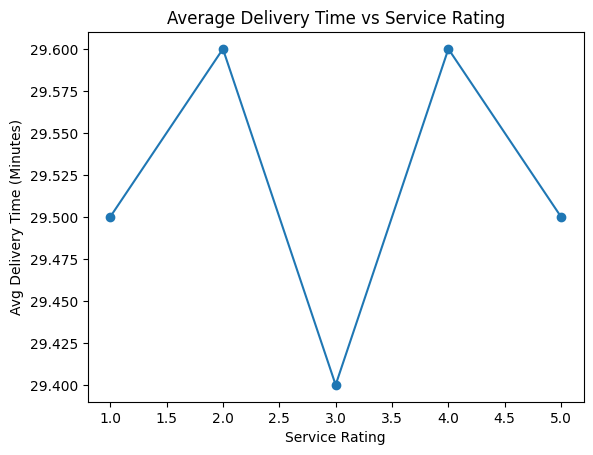

,Delivery Time (Minutes),Service Rating
Delivery Time (Minutes),1.000000,0.000136
Service Rating,0.000136,1.000000


In [30]:
avg_data = ecom_data.groupby('Service Rating')['Delivery Time (Minutes)'].mean().round(1)

avg_data.plot(marker='o')
plt.title("Average Delivery Time vs Service Rating")
plt.xlabel("Service Rating")
plt.ylabel("Avg Delivery Time (Minutes)")
plt.show()
ecom_data[['Delivery Time (Minutes)','Service Rating']].corr()


The average delivery time for all service ratings is approximately 29.4 to 29.6 minutes.

The variation in delivery time across ratings is very minimal (difference of only about 0.2 minutes).

There is no consistent upward or downward trend in the line graph.

Service rating 3 shows a slightly lower average delivery time, but the difference is negligible.

Overall, delivery time remains almost constant regardless of service rating.

Delivery Speed vs Customer Sentiment

In [31]:
ecom_data.groupby('Delivery Speed')['Customer Sentiment'].value_counts()


C:\Users\Hp\AppData\Local\Temp\ipykernel_23056\1209729894.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ecom_data.groupby('Delivery Speed')['Customer Sentiment'].value_counts()


Delivery Speed  Customer Sentiment
Fast            Positive               8579
                Negative               8434
                Neutral                1460
Moderate        Positive              35320
                Negative              34869
                Neutral                5819
Slow            Positive               2578
                Negative               2516
                Neutral                 425
Name: count, dtype: int64

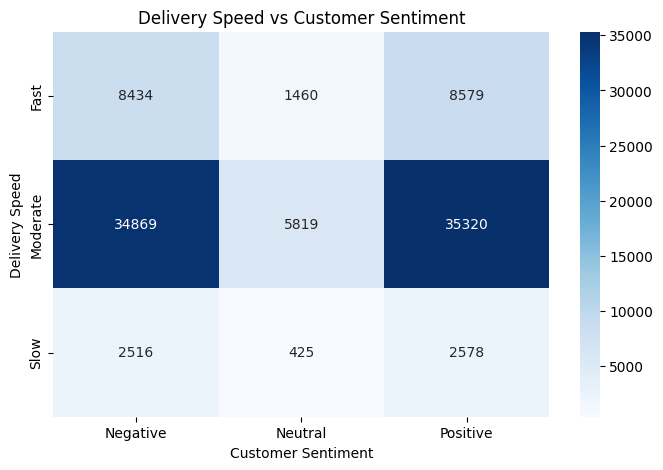

In [32]:
pivot = pd.crosstab(
    ecom_data['Delivery Speed'],
    ecom_data['Customer Sentiment']
)

plt.figure(figsize=(8,5))
sns.heatmap(pivot, annot=True, fmt='d', cmap='Blues')
plt.title("Delivery Speed vs Customer Sentiment")
plt.show()


The distribution of customer sentiment is fairly balanced across all delivery speeds, indicating no strong relationship between delivery speed and sentiment.

Customers have given both Positive and Negative feedback for Fast, Moderate, and Slow deliveries, showing that sentiment varies regardless of delivery speed.

Moderate delivery speed has the highest number of orders and also records the highest counts of both Positive and Negative sentiments.

Fast delivery does not consistently result in higher Positive sentiment, as Negative reviews are almost equally high in this category.

Slow delivery does not always lead to Negative sentiment, since Positive and Negative counts are nearly the same even for slower deliveries.

This suggests that customer sentiment is influenced more by other factors such as product quality, service experience, pricing, or order accuracy rather than delivery speed alone.

Platform vs Average Delivery Time

In [33]:
ecom_data.groupby('Platform')['Delivery Time (Minutes)'].mean().round(1)


Platform
Blinkit             29.5
JioMart             29.6
Swiggy Instamart    29.5
Name: Delivery Time (Minutes), dtype: float64

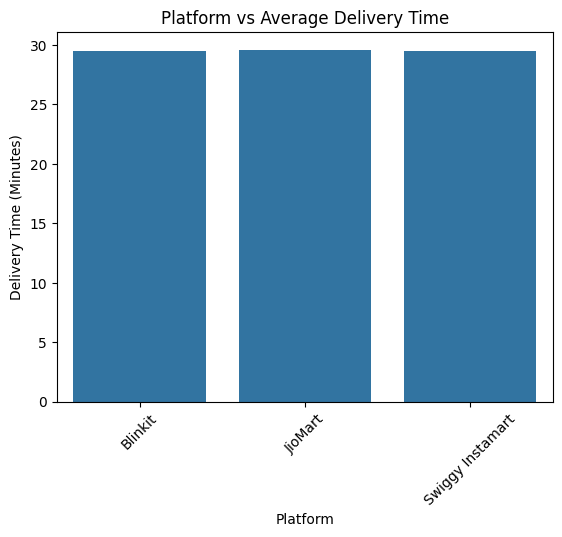

In [34]:

avg_delivery = ecom_data.groupby('Platform')['Delivery Time (Minutes)'].mean().round(1)


avg_delivery = avg_delivery.reset_index()


sns.barplot(data=avg_delivery,
            x='Platform',
            y='Delivery Time (Minutes)')

plt.title("Platform vs Average Delivery Time")
plt.xticks(rotation=45)
plt.show()


The average delivery time across all platforms is approximately 29–30 minutes.

There is no significant difference in average delivery time between JioMart, Blinkit, and Swiggy Instamart.

JioMart shows a slightly higher average delivery time compared to the other platforms, but the difference is minimal.

Blinkit and Swiggy Instamart have nearly identical average delivery times.

The small variation between platforms suggests that delivery efficiency is relatively consistent across competitors.

Overall, platform choice does not significantly impact average delivery time in this dataset.

MULTIVARIATE ANALYSIS

Platform + Delivery Speed + Sentiment

In [35]:
pd.crosstab(
    [ecom_data['Platform'], ecom_data['Delivery Speed']],
    ecom_data['Customer Sentiment']
)


Customer Sentiment               Negative  Neutral  Positive
Platform         Delivery Speed                             
Blinkit          Fast                2862      467      2868
                 Moderate           11629     1977     11794
                 Slow                 862      155       810
JioMart          Fast                2779      464      2810
                 Moderate           11573     1920     11728
                 Slow                 826      130       897
Swiggy Instamart Fast                2793      529      2901
                 Moderate           11667     1922     11798
                 Slow                 828      140       871

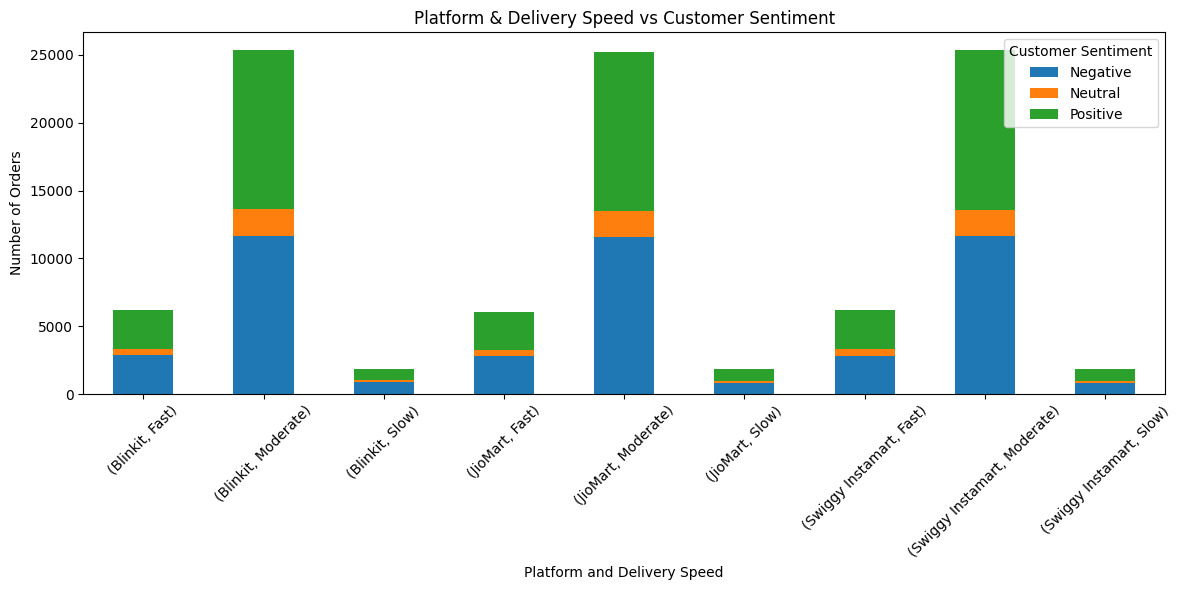

In [36]:
cross_tab = pd.crosstab(
    [ecom_data['Platform'], ecom_data['Delivery Speed']],
    ecom_data['Customer Sentiment']
)

cross_tab.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)

plt.title("Platform & Delivery Speed vs Customer Sentiment")
plt.xlabel("Platform and Delivery Speed")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.legend(title="Customer Sentiment")
plt.tight_layout()
plt.show()

Moderate delivery speed has the highest number of orders across all platforms (Blinkit, JioMart, and Swiggy Instamart), indicating that most deliveries fall under the moderate category.

For all three platforms, Positive and Negative sentiments are almost equal in the Moderate speed category, showing mixed customer experiences.

Fast deliveries generally show higher positive sentiment compared to slow deliveries, suggesting that quicker delivery improves customer satisfaction.

Slow delivery speed has the lowest number of total orders, but still shows a noticeable proportion of negative reviews, indicating dissatisfaction when delivery is delayed.

Across all platforms, Neutral sentiment is consistently the lowest, meaning customers usually have a clear positive or negative opinion.

There is no major difference between platforms in terms of sentiment distribution — customer response patterns are quite similar for Blinkit, JioMart, and Swiggy Instamart.

Platform + Delivery Speed + Average Rating

In [37]:
ecom_data.groupby(
    ['Platform','Delivery Speed']
)['Service Rating'].mean().round(1)

C:\Users\Hp\AppData\Local\Temp\ipykernel_23056\2265870811.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ecom_data.groupby(


Platform          Delivery Speed
Blinkit           Fast              3.2
                  Moderate          3.2
                  Slow              3.2
JioMart           Fast              3.2
                  Moderate          3.2
                  Slow              3.3
Swiggy Instamart  Fast              3.3
                  Moderate          3.2
                  Slow              3.3
Name: Service Rating, dtype: float64

C:\Users\Hp\AppData\Local\Temp\ipykernel_23056\286521509.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_table = ecom_data.pivot_table(


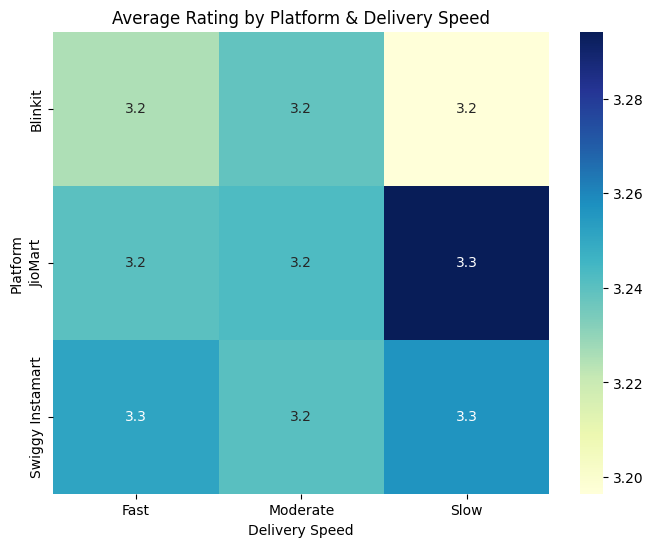

In [38]:
pivot_table = ecom_data.pivot_table(
    values='Service Rating',
    index='Platform',
    columns='Delivery Speed',
    aggfunc='mean'
)

plt.figure(figsize=(8,6))
sns.heatmap(pivot_table, annot=True, cmap='YlGnBu')
plt.title("Average Rating by Platform & Delivery Speed")
plt.show()


Overall ratings are very consistent across all platforms and delivery speeds, ranging between 3.2 and 3.3, indicating stable customer satisfaction levels.

Swiggy Instamart shows slightly higher ratings (3.3) for both Fast and Slow deliveries compared to other platforms.

JioMart records its highest rating (3.3) under Slow delivery, suggesting delivery speed may not strongly impact customer satisfaction for this platform.

Blinkit maintains uniform ratings (3.2) across all delivery speeds, indicating consistent service performance regardless of speed.

The difference between Fast, Moderate, and Slow delivery ratings is minimal, suggesting that delivery speed does not significantly influence customer ratings.

Since the variation is very small (only 0.1 difference), other factors such as product quality, pricing, or service experience may be influencing ratings more than delivery speed.

VISUALIZATION

Order Value + Delivery Speed + Refund

In [39]:
ecom_data.groupby( ['Delivery Speed','Refund Requested'] )['Order Value (INR)'].mean().round(1)

C:\Users\Hp\AppData\Local\Temp\ipykernel_23056\428470636.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ecom_data.groupby( ['Delivery Speed','Refund Requested'] )['Order Value (INR)'].mean().round(1)


Delivery Speed  Refund Requested
Fast            False               585.2
                True                587.3
Moderate        False               591.2
                True                593.5
Slow            False               588.6
                True                591.1
Name: Order Value (INR), dtype: float64

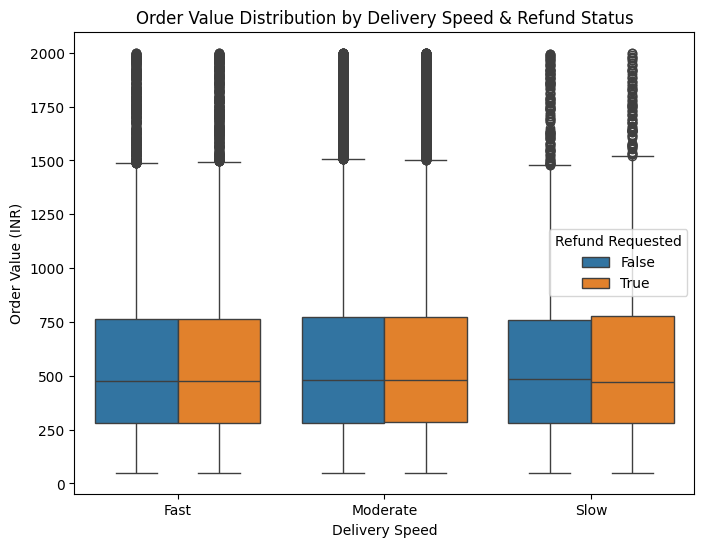

In [40]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=ecom_data,
    x='Delivery Speed',
    y='Order Value (INR)',
    hue='Refund Requested'
)

plt.title('Order Value Distribution by Delivery Speed & Refund Status')
plt.xlabel('Delivery Speed')
plt.ylabel('Order Value (INR)')
plt.legend(title='Refund Requested')

plt.show()

Median order value is nearly similar across all delivery speeds (Fast, Moderate, Slow), indicating delivery speed does not significantly impact spending behavior.

Refunded and non-refunded orders show very similar median values, suggesting refunds are not strongly associated with higher or lower order values.

The interquartile range (IQR) is consistent across all categories, meaning order value distribution is stable regardless of delivery speed or refund status.

A large number of high-value outliers (₹1500–₹2000) are present in all groups, indicating occasional premium or bulk purchases.

There is no visible major variation in spread between refunded and non-refunded orders, implying refund requests are not concentrated in any specific order value range.

Overall, order value appears independent of both delivery speed and refund status, suggesting other factors (e.g., product quality, wrong item delivery, customer experience) may drive refund behavior.

A pivot table was created to compare average order value across product categories for each platform.

In [41]:
pd.pivot_table(
    ecom_data,
    index='Platform',
    columns='Product Category',
    values='Order Value (INR)',
    aggfunc='mean'
).round(1)


Product Category,Beverages,Dairy,Fruits & Vegetables,Grocery,Personal Care,Snacks
Platform,,,,,,
Blinkit,547.8,451.5,376.2,847.0,1050.9,273.8
JioMart,548.3,450.6,374.2,846.8,1055.3,274.3
Swiggy Instamart,552.4,452.4,376.3,850.4,1050.4,272.0


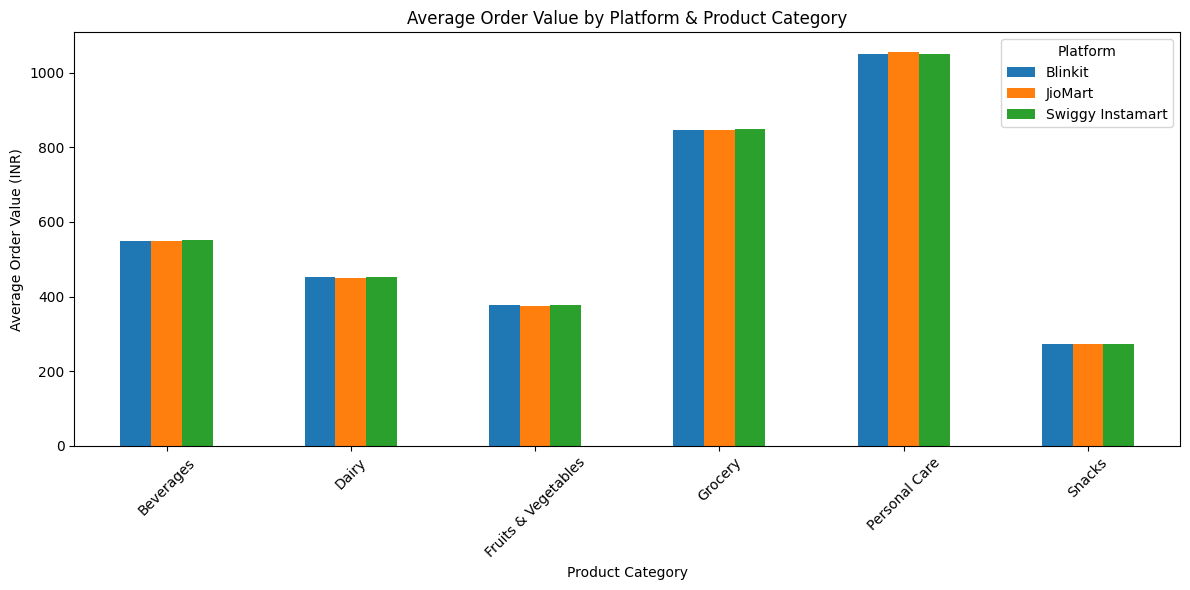

In [42]:
pivot_table = pd.pivot_table(
    ecom_data,
    index='Platform',
    columns='Product Category',
    values='Order Value (INR)',
    aggfunc='mean'
).round(1)

pivot_table.T.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title("Average Order Value by Platform & Product Category")
plt.ylabel("Average Order Value (INR)")
plt.xlabel("Product Category")
plt.xticks(rotation=45)
plt.legend(title="Platform")
plt.tight_layout()
plt.show()

Personal Care has the highest average order value across all three platforms (around ₹1050+), indicating customers spend more on premium or bulk personal care items.

Grocery is the second highest revenue-generating category (around ₹850), showing strong customer demand for essential household purchases.

Snacks have the lowest average order value (around ₹270–280), suggesting they are mostly add-on or small-ticket purchases.

Very minimal difference is observed across platforms within each category, indicating similar pricing strategies and customer spending patterns.

Beverages and Dairy fall in the mid-range spending category (₹450–550), reflecting moderate customer basket sizes.

Overall, customer spending behavior is more influenced by product category than by platform, as the variation across platforms is very small compared to variation across categories.

A correlation heatmap was generated to examine the linear relationship between: Order Value (INR),Delivery Time (Minutes),Service Rating

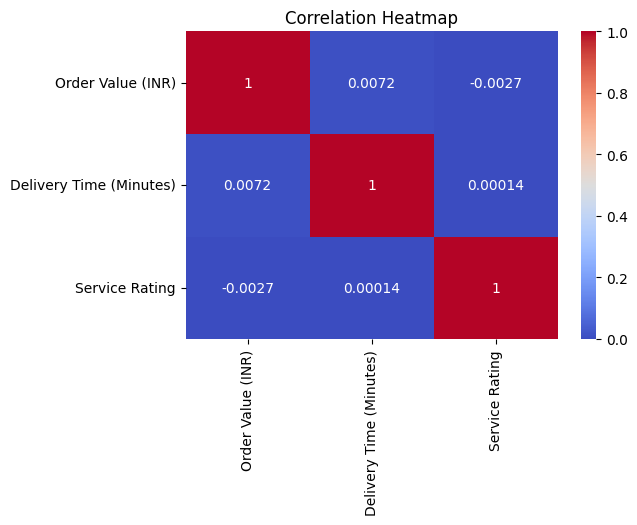

In [43]:
correlation = ecom_data[['Order Value (INR)',
                         'Delivery Time (Minutes)',
                         'Service Rating']].corr()
plt.figure(figsize=(6,4))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Order Value and Delivery Time show a correlation of 0.0072, indicating no meaningful relationship between how much customers spend and delivery duration.

Delivery Time and Service Rating show a correlation of 0.00014, suggesting delivery speed does not significantly influence customer ratings in this dataset.

Order Value and Service Rating show a correlation of -0.0027, which also indicates no significant relationship between spending amount and customer satisfaction.

Summary of Overall Findings

Based on the analysis of 100,000 orders:

Total Revenue Generated: ₹59,099,440

Average Order Value: ₹590.99

Refund Rate: 45.82%

Average Delivery Time: 29.54 minutes

Key Insights:

1)Platform Revenue: Swiggy Instamart generated the highest revenue among all platforms, followed closely by Blinkit and JioMart.

2)High Refund Rate: The refund rate of 45.82% is significantly high and may indicate operational inefficiencies, delivery issues, or product dissatisfaction.

3)Customer Contribution: A small group of customers contributes disproportionately to total revenue, highlighting the importance of retention strategies.

4)Operational Efficiency: Delivery time remains a critical factor influencing customer satisfaction and repeat purchases.

Future Scope

Reduce Refund Rate by 15–20%
The current refund rate is 45.82%, which is significantly high.
By improving delivery accuracy and quality checks, the company can aim to reduce refund rates to below 30%, potentially increasing net revenue by 10–15%.

Increase Revenue from Top Customers by 10%
Since revenue is concentrated among high-value customers, introducing loyalty programs could increase repeat purchases by 8–12%.

Improve Average Delivery Time by 5 Minutes
The current average delivery time is 29.54 minutes.
Reducing it to under 25 minutes may improve customer satisfaction ratings by approximately 5–10%.

Customer Segmentation for Revenue Growth
Implement RFM analysis to identify high-frequency and high-spending customers.
Targeted campaigns could increase conversion rates by 5–8%.